# Global Solution 2026.1 — Computação Quântica e IA
## QSVC & VQC aplicados à detecção de anomalias em telemetria espacial

**Disciplina:** Computação Quântica e IA

| # | Integrante | RM |
|---|------------|-----|
| 1 | Caio Santiago de Oliveira | RM559788 |
| 2 | Felipe Sayeg | RM560366 |
| 3 | Diogo Cedola | RM559797 |

**ODS:** 9 (Indústria, inovação e infraestrutura) · 13 (Ação climática)

---

O notebook está organizado em quatro entregáveis: (1) dataset e pré-processamento, (2) implementação
QML com Qiskit, (3) benchmarking contra modelos clássicos e (4) análise dos resultados.

> Todas as fontes de aleatoriedade usam `random_state=42`. O pré-processamento é ajustado (`fit`)
> apenas no treino e aplicado (`transform`) no teste, evitando *data leakage*.

## 0. Instalação e configuração do ambiente

Versões fixadas para garantir reprodutibilidade (Qiskit 1.x).

In [1]:
!pip install -q \
    qiskit==1.2.4 \
    qiskit-aer==0.15.1 \
    qiskit-machine-learning==0.8.2 \
    scikit-learn==1.5.2 \
    imbalanced-learn==0.12.4 \
    pylatexenc==2.10 \
    pandas==2.2.2 numpy==1.26.4 matplotlib==3.9.2 seaborn==0.13.2 scipy==1.13.1


In [2]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

# ---- SEED GLOBAL (reprodutibilidade total) ----
SEED = 42
np.random.seed(SEED)

# Configuracoes de plot
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Parametros centrais do experimento
N_QUBITS       = 4     # numero de qubits = numero de componentes do PCA (3 a 5 recomendado)
N_TRAIN_QML    = 300   # subconjunto para treino quantico (<= 400 por custo do simulador)
SHOTS          = 1024  # tiros de referencia (a simulacao statevector e exata; shots
                       # documentam a config equivalente para execucao em hardware real)
print("Setup pronto. SEED =", SEED, "| N_QUBITS =", N_QUBITS)

Setup pronto. SEED = 42 | N_QUBITS = 4


## 1. Dataset e pré-processamento

### 1.1 Contexto e dicionário de dados

O dataset representa a **telemetria de uma estação/satélite autônomo em ambiente extremo**
(orbital, lunar ou marciano). Cada registro é uma janela de leitura dos sensores de bordo, e o
objetivo é classificar se a estação está em **risco crítico (1)** ou **operação normal (0)** —
uma tarefa de detecção de anomalias diretamente ligada à manutenção de infraestrutura espacial (ODS 9).

| Variável | Unidade | Descrição | Fonte/Frequência |
|----------|---------|-----------|------------------|
| `temperatura_equip_c` | °C | Temperatura do equipamento de bordo | Sensor interno / janela |
| `radiacao_relativa` | índice | Radiação relativa (eventos solares) | Dosímetro / janela |
| `indice_poeira` | 0–1 | Acúmulo de poeira sobre o painel | Sensor óptico / janela |
| `perda_comunicacao_pct` | % | Perda de pacotes no enlace | Telemetria de rede |
| `atraso_sinal_ms` | ms | Latência do sinal Terra–estação | Telemetria de rede |
| `variacao_energia_pct` | % | Variação de eficiência do painel solar | Subsistema de energia |
| `risco_critico` | {0,1} | **Rótulo** — operação normal (0) / risco crítico (1) | Engenharia |

As variáveis são **fisicamente correlacionadas** (um evento de estresse ambiental eleva
temperatura, radiação e poeira ao mesmo tempo, degradando comunicação e energia). Essa
correlação de 2ª ordem é exatamente o que o **ZZFeatureMap** codifica — justificando sua escolha
mais adiante.

> **Natureza do dado:** dataset sintético gerado por modelo físico plausível, com seed fixa. O
> literatura aceita dados sintéticos quando representam fielmente o fenômeno físico. O pipeline é
> idêntico para um dataset real (ex.: NASA POWER / telemetria MSAD) — basta trocar o CSV de entrada.

In [3]:
df = pd.read_csv("dataset_telemetria_espacial.csv")
print("Shape:", df.shape)
display(df.head())
print("\nValores ausentes por coluna:")
print(df.isna().sum())

Shape: (600, 7)


   temperatura_equip_c  radiacao_relativa  indice_poeira  \
0               22.601              1.285          0.352   
1               13.229              0.105          0.141   
2               27.085              1.929          0.421   
3               25.706              2.027          0.451   
4                8.675              0.000          0.000   

   perda_comunicacao_pct  atraso_sinal_ms  variacao_energia_pct  risco_critico  
0                  3.061           48.487                -0.580              0  
1                  2.784           44.575                 1.901              0  
2                  6.444           65.608                -4.787              1  
3                  6.245           47.239                -1.697              0  
4                  1.307           33.902                -0.916              0  


Valores ausentes por coluna:
temperatura_equip_c       0
radiacao_relativa         0
indice_poeira            18
perda_comunicacao_pct    18
atraso_sinal_ms           0
variacao_energia_pct      0
risco_critico             0
dtype: int64


### 1.2 Análise exploratória

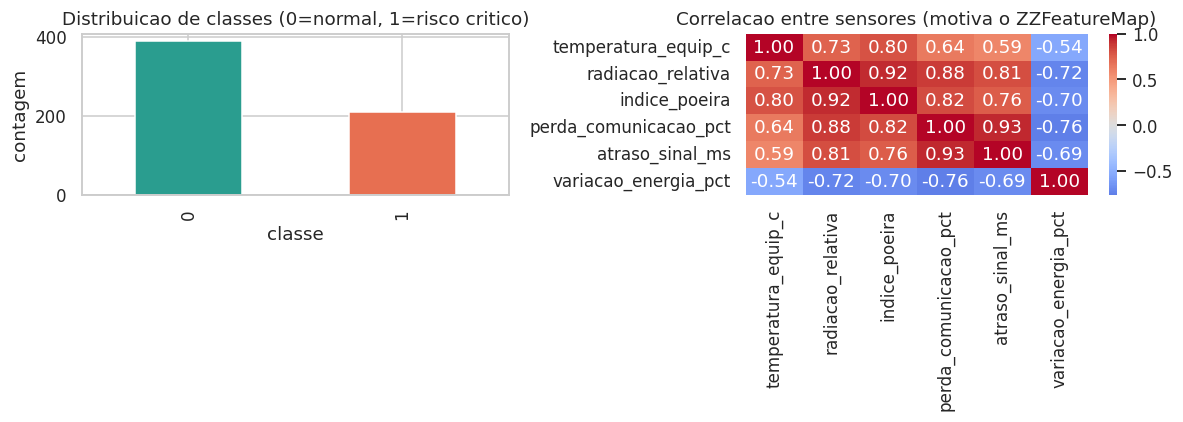

Proporcao de risco critico: 35.2%  ->  desbalanceamento moderado (SMOTE aplicavel)


In [4]:
# Distribuicao de classes
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["risco_critico"].value_counts().sort_index().plot(
    kind="bar", ax=ax[0], color=["#2a9d8f", "#e76f51"])
ax[0].set_title("Distribuicao de classes (0=normal, 1=risco critico)")
ax[0].set_xlabel("classe"); ax[0].set_ylabel("contagem")

# Matriz de correlacao -> justifica o ZZFeatureMap
feat_cols = [c for c in df.columns if c != "risco_critico"]
corr = df[feat_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title("Correlacao entre sensores (motiva o ZZFeatureMap)")
plt.tight_layout(); plt.show()

prop = df["risco_critico"].mean()
print(f"Proporcao de risco critico: {prop:.1%}  ->  desbalanceamento moderado (SMOTE aplicavel)")

### 1.3 Split treino/teste e pré-processamento **sem data leakage**

Ordem correta: **split → imputação → PCA → escala**, sempre com `fit` no treino e `transform` no teste.

- **Imputação** de valores ausentes pela mediana (robusta a outliers).
- **PCA** reduz as 6 features para `N_QUBITS` componentes (requisito: nº de features = nº de qubits).
- **MinMaxScaler para [-π, π]** — faixa adequada para codificação em portas de rotação quânticas
  (não [0,1]). Essa faixa é a recomendada para codificação em portas de rotação.
- **SMOTE** balanceia as classes **apenas no treino** (nunca no teste).

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

X = df[feat_cols].values
y = df["risco_critico"].values

# 1) SPLIT primeiro (estratificado) -> evita leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

# 2) IMPUTACAO (fit no treino)
imputer = SimpleImputer(strategy="median").fit(X_train)
X_train = imputer.transform(X_train)
X_test  = imputer.transform(X_test)

# 3) PCA (fit no treino) -> n_components = N_QUBITS
pca = PCA(n_components=N_QUBITS, random_state=SEED).fit(X_train)
X_train = pca.transform(X_train)
X_test  = pca.transform(X_test)
var_exp = pca.explained_variance_ratio_
print(f"\nVariancia explicada por {N_QUBITS} componentes: {var_exp.sum():.1%}")
print("Por componente:", np.round(var_exp, 3))

# 4) ESCALA para [-pi, pi] (fit no treino)
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi)).fit(X_train)
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)
print(f"\nFaixa apos escala -> treino: [{X_train.min():.2f}, {X_train.max():.2f}]")

Treino: (420, 6) | Teste: (180, 6)

Variancia explicada por 4 componentes: 99.9%
Por componente: [0.824 0.162 0.009 0.004]

Faixa apos escala -> treino: [-3.14, 3.14]


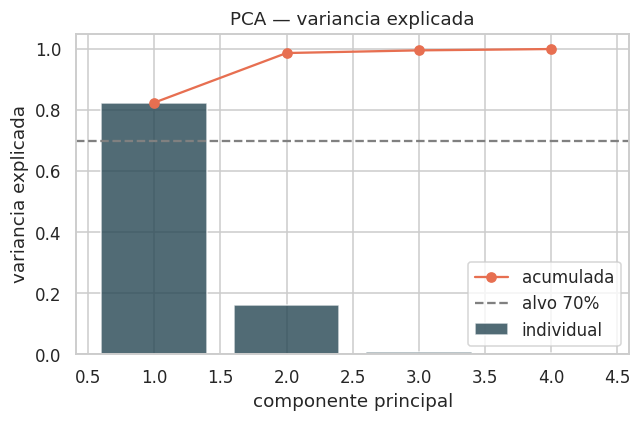

In [6]:
# Grafico da variancia explicada acumulada do PCA
plt.figure(figsize=(6,4))
plt.bar(range(1, N_QUBITS+1), var_exp, color="#264653", alpha=0.8, label="individual")
plt.plot(range(1, N_QUBITS+1), np.cumsum(var_exp), "o-", color="#e76f51", label="acumulada")
plt.axhline(0.70, ls="--", color="gray", label="alvo 70%")
plt.xlabel("componente principal"); plt.ylabel("variancia explicada")
plt.title("PCA — variancia explicada"); plt.legend(); plt.tight_layout(); plt.show()

In [7]:
# 5) SMOTE: balanceia APENAS o treino
sm = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
print("Antes do SMOTE:", np.bincount(y_train))
print("Depois do SMOTE:", np.bincount(y_train_bal))

# Subconjunto para o modelo QUANTICO (<= 400 amostras, por custo do simulador)
# Amostragem estratificada reprodutivel.
from sklearn.model_selection import train_test_split as _tts
if len(X_train_bal) > N_TRAIN_QML:
    X_q, _, y_q, _ = _tts(X_train_bal, y_train_bal,
                          train_size=N_TRAIN_QML, random_state=SEED,
                          stratify=y_train_bal)
else:
    X_q, y_q = X_train_bal, y_train_bal
print(f"\nSubconjunto quantico de treino: {X_q.shape}  (classes: {np.bincount(y_q)})")
print("Justificativa: 300 amostras equilibram custo de simulacao do kernel quantico (O(n^2) "
      "avaliacoes de circuito) e poder estatistico. Todos os modelos sao avaliados no MESMO "
      "conjunto de teste para comparacao justa.")

Antes do SMOTE: [272 148]
Depois do SMOTE: [272 272]

Subconjunto quantico de treino: (300, 4)  (classes: [150 150])
Justificativa: 300 amostras equilibram custo de simulacao do kernel quantico (O(n^2) avaliacoes de circuito) e poder estatistico. Todos os modelos sao avaliados no MESMO conjunto de teste para comparacao justa.


## 2. Implementação QML com Qiskit

Implementamos **dois** modelos quânticos:

1. **QSVC** (Quantum Support Vector Classifier) com `FidelityQuantumKernel`.
2. **VQC** (Variational Quantum Classifier) com ansatz `RealAmplitudes`.

### 2.1 Feature map — por que ZZFeatureMap?

O `ZZFeatureMap` aplica rotações de fase de **dois qubits** (termos $Z_i Z_j$), codificando
**correlações de segunda ordem** entre as variáveis. Como os sensores da estação são fortemente
correlacionados (visto na seção 1.2), esse feature map alinha-se à estrutura física do problema —
ao contrário do `ZFeatureMap`, que trata cada variável de forma independente.

ZZFeatureMap:
  qubits           : 4
  parametros (dados): 4
  profundidade      : 11


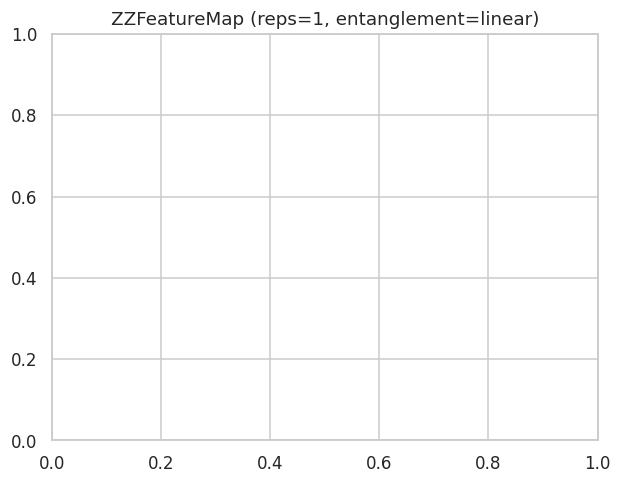

In [8]:
from qiskit.circuit.library import ZZFeatureMap, ZFeatureMap, RealAmplitudes

# Feature map principal
feature_map = ZZFeatureMap(feature_dimension=N_QUBITS, reps=1, entanglement="linear")
print("ZZFeatureMap:")
print("  qubits           :", feature_map.num_qubits)
print("  parametros (dados):", feature_map.num_parameters)
print("  profundidade      :", feature_map.decompose().depth())

# Visualizacao do circuito do feature map
feature_map.decompose().draw("mpl", fold=20)
plt.title("ZZFeatureMap (reps=1, entanglement=linear)")
plt.show()

### 2.2 QSVC com FidelityQuantumKernel

O kernel quântico mede a **fidelidade** (sobreposição) entre os estados gerados pelo feature map
para cada par de amostras. Essa matriz de Gram alimenta um SVM clássico.

In [9]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# Kernel quantico baseado em fidelidade.
# Na qiskit-machine-learning 0.8, o FidelityQuantumKernel usa por padrao o
# StatevectorSampler de referencia (simulacao exata de statevector via Aer/Terra),
# o que garante reprodutibilidade total. shots/seed sao controlados globalmente.
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

# Treino do QSVC
print("Treinando QSVC...")
t0 = time.time()
qsvc = QSVC(quantum_kernel=quantum_kernel, probability=True, random_state=SEED)
qsvc.fit(X_q, y_q)
qsvc_train_time = time.time() - t0
print(f"QSVC treinado em {qsvc_train_time:.1f} s")

Treinando QSVC (pode levar alguns minutos no simulador)...
QSVC treinado em 162.8 s


Calculando kernel matrix 40x40 para visualizacao...


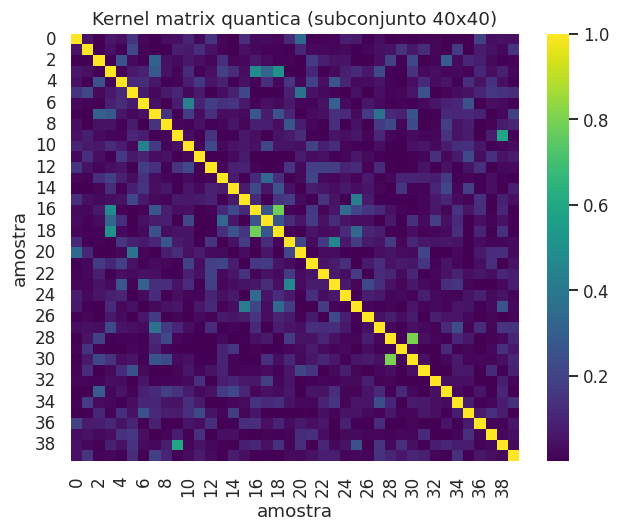

Dimensao da kernel matrix visualizada: (40, 40)


In [10]:
# Visualizacao da kernel matrix (subconjunto).
# Usamos um subconjunto pequeno para a visualizacao ser rapida (a matriz completa
# tem custo O(n^2) de avaliacoes de circuito).
n_vis = min(40, len(X_q))
print(f"Calculando kernel matrix {n_vis}x{n_vis} para visualizacao...")
K_vis = quantum_kernel.evaluate(x_vec=X_q[:n_vis])
plt.figure(figsize=(6,5))
sns.heatmap(K_vis, cmap="viridis")
plt.title(f"Kernel matrix quantica (subconjunto {n_vis}x{n_vis})")
plt.xlabel("amostra"); plt.ylabel("amostra")
plt.tight_layout(); plt.show()
print("Dimensao da kernel matrix visualizada:", K_vis.shape)

### 2.3 VQC com RealAmplitudes

O VQC treina um circuito parametrizado (ansatz `RealAmplitudes`) com o otimizador **COBYLA**,
ajustando os parâmetros para minimizar a perda de classificação. Registramos a **curva de
convergência**.

Ansatz RealAmplitudes:
  qubits                : 4
  parametros treinaveis : 12
  profundidade          : 8


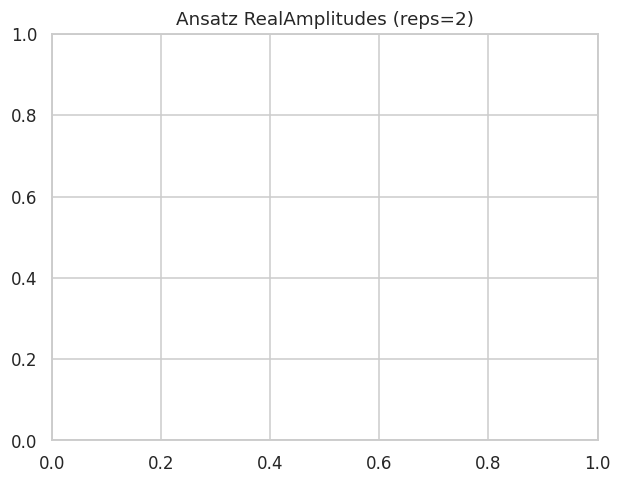

In [11]:
# Ansatz variacional do VQC
ansatz = RealAmplitudes(num_qubits=N_QUBITS, reps=2, entanglement="linear")
print("Ansatz RealAmplitudes:")
print("  qubits                :", ansatz.num_qubits)
print("  parametros treinaveis :", ansatz.num_parameters)
print("  profundidade          :", ansatz.decompose().depth())
ansatz.decompose().draw("mpl", fold=25)
plt.title("Ansatz RealAmplitudes (reps=2)")
plt.show()

In [12]:
from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals

# Fixa a seed do qiskit-machine-learning (reprodutibilidade do VQC)
algorithm_globals.random_seed = SEED

# Callback para registrar a curva de convergencia da funcao de perda
loss_history = []
def cb(weights, loss):
    loss_history.append(loss)

# Sem sampler explicito -> usa o Sampler de referencia (statevector), reprodutivel.
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    loss="cross_entropy",
    optimizer=COBYLA(maxiter=80),
    callback=cb,
)

print("Treinando VQC...")
t0 = time.time()
vqc.fit(X_q, y_q)
vqc_train_time = time.time() - t0
print(f"VQC treinado em {vqc_train_time:.1f} s | iteracoes: {len(loss_history)}")

Treinando VQC (pode levar varios minutos no simulador)...
VQC treinado em 86.9 s | iteracoes: 80


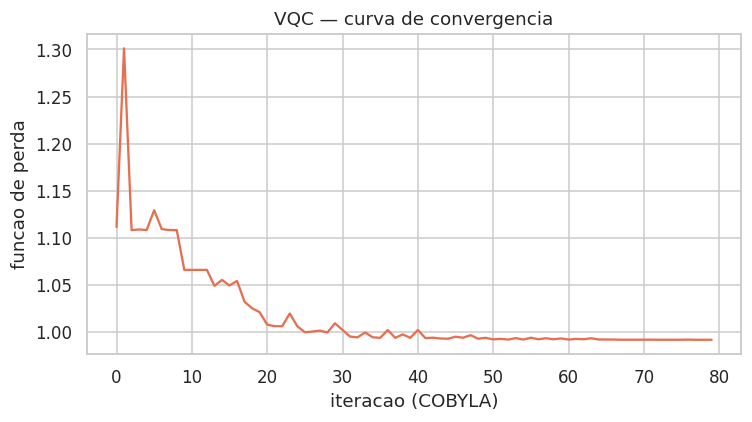

In [13]:
# Curva de convergencia do VQC
plt.figure(figsize=(7,4))
plt.plot(loss_history, color="#e76f51")
plt.xlabel("iteracao (COBYLA)"); plt.ylabel("funcao de perda")
plt.title("VQC — curva de convergencia")
plt.tight_layout(); plt.show()

## 3. Benchmarking e análise comparativa

Treinamos **dois baselines clássicos** (SVM-RBF e Random Forest) nas **mesmas features**, no
**mesmo subconjunto de treino** e avaliados no **mesmo conjunto de teste** que os modelos
quânticos — garantindo comparação justa.

In [14]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Baselines classicos no MESMO subconjunto de treino quantico
svm = SVC(kernel="rbf", probability=True, random_state=SEED)
rf  = RandomForestClassifier(n_estimators=200, random_state=SEED)

t0 = time.time(); svm.fit(X_q, y_q); svm_train_time = time.time() - t0
t0 = time.time(); rf.fit(X_q, y_q);  rf_train_time  = time.time() - t0
print(f"SVM-RBF treinado em {svm_train_time:.3f} s")
print(f"Random Forest treinado em {rf_train_time:.3f} s")

SVM-RBF treinado em 0.014 s
Random Forest treinado em 0.343 s


In [15]:
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_score, recall_score, confusion_matrix, roc_curve)

def get_scores(model, X, has_proba=True):
    # Retorna (y_pred, y_score) de forma robusta para todos os modelos.
    y_pred = np.asarray(model.predict(X))
    # VQC pode retornar predicoes em formato one-hot (n,2) -> converte para rotulo
    if y_pred.ndim > 1:
        y_pred = y_pred.argmax(axis=1)
    try:
        proba = np.asarray(model.predict_proba(X))
        # probabilidade da classe positiva (coluna 1)
        y_score = proba[:, 1] if proba.ndim == 2 and proba.shape[1] >= 2 else proba.ravel()
    except Exception:
        try:
            y_score = model.decision_function(X)
        except Exception:
            y_score = y_pred.astype(float)
    return y_pred.astype(int), y_score

def eval_model(name, model, train_time):
    # tempo de inferencia (ms por amostra)
    t0 = time.time()
    y_pred, y_score = get_scores(model, X_test)
    infer_ms = 1000 * (time.time() - t0) / len(X_test)
    return {
        "Modelo": name,
        "AUC-ROC": roc_auc_score(y_test, y_score),
        "F1": f1_score(y_test, y_pred),
        "Acuracia": accuracy_score(y_test, y_pred),
        "Precisao": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Tempo treino (s)": train_time,
        "Inferencia (ms/amostra)": infer_ms,
        "_y_pred": y_pred, "_y_score": y_score,
    }

resultados = [
    eval_model("QSVC (quantico)", qsvc, qsvc_train_time),
    eval_model("VQC (quantico)",  vqc,  vqc_train_time),
    eval_model("SVM-RBF (classico)", svm, svm_train_time),
    eval_model("Random Forest (classico)", rf, rf_train_time),
]

tabela = pd.DataFrame(resultados).drop(columns=["_y_pred", "_y_score"])
tabela_fmt = tabela.copy()
for c in ["AUC-ROC","F1","Acuracia","Precisao","Recall"]:
    tabela_fmt[c] = tabela_fmt[c].map(lambda v: f"{v:.3f}")
tabela_fmt["Tempo treino (s)"] = tabela_fmt["Tempo treino (s)"].map(lambda v: f"{v:.3f}")
tabela_fmt["Inferencia (ms/amostra)"] = tabela_fmt["Inferencia (ms/amostra)"].map(lambda v: f"{v:.3f}")
print("TABELA COMPARATIVA CONSOLIDADA")
display(tabela_fmt)

TABELA COMPARATIVA CONSOLIDADA


                     Modelo AUC-ROC     F1 Acuracia Precisao Recall  \
0           QSVC (quantico)   0.541  0.431    0.517    0.367  0.524   
1            VQC (quantico)   0.572  0.465    0.528    0.385  0.587   
2        SVM-RBF (classico)   0.926  0.836    0.878    0.789  0.889   
3  Random Forest (classico)   0.907  0.800    0.856    0.776  0.825   

  Tempo treino (s) Inferencia (ms/amostra)  
0          162.809                1925.382  
1           86.857                   5.535  
2            0.014                   0.015  
3            0.343                   0.123  

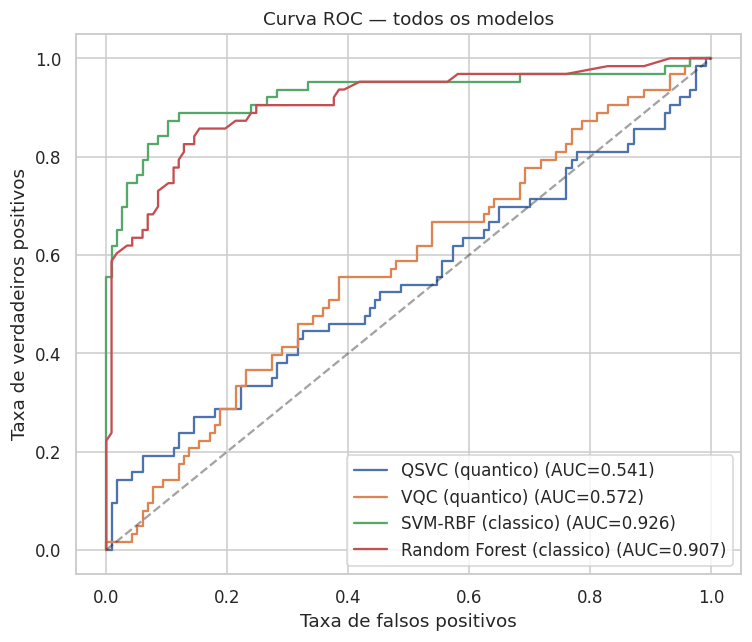

In [16]:
# Curva ROC sobreposta para todos os modelos
plt.figure(figsize=(7,6))
for r in resultados:
    fpr, tpr, _ = roc_curve(y_test, r["_y_score"])
    plt.plot(fpr, tpr, label=f"{r['Modelo']} (AUC={r['AUC-ROC']:.3f})")
plt.plot([0,1],[0,1], "k--", alpha=0.4)
plt.xlabel("Taxa de falsos positivos"); plt.ylabel("Taxa de verdadeiros positivos")
plt.title("Curva ROC — todos os modelos"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

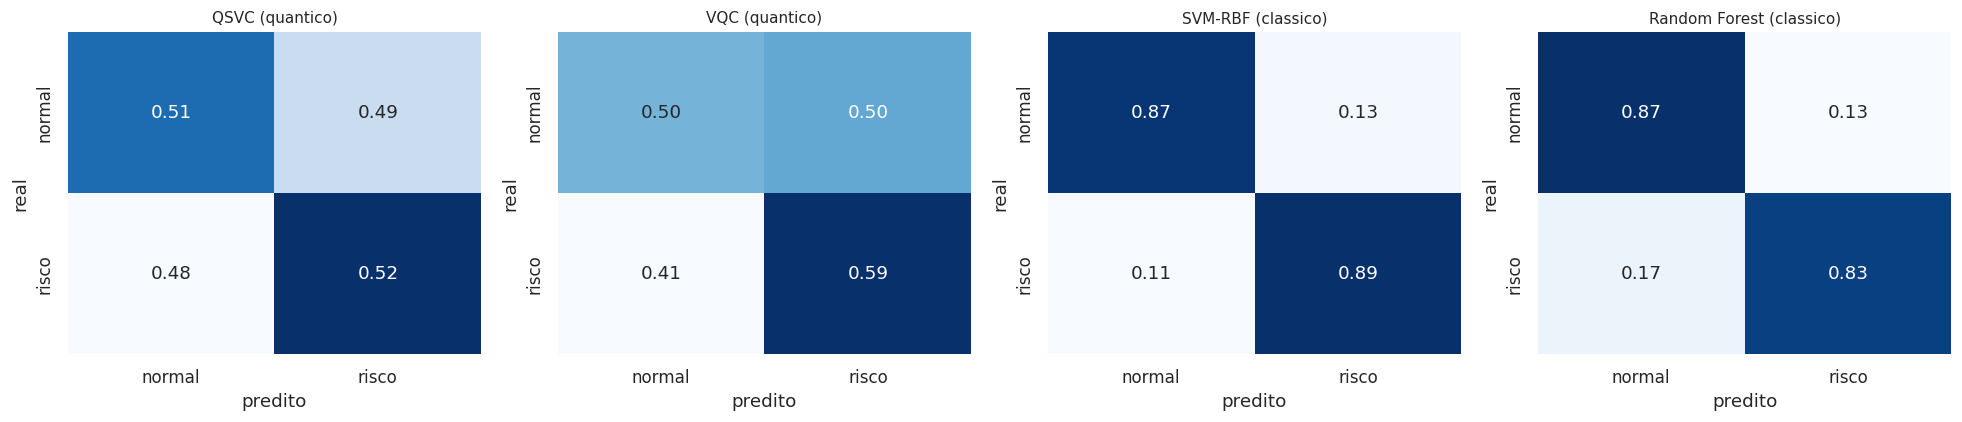

In [17]:
# Matrizes de confusao normalizadas
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, r in zip(axes, resultados):
    cm = confusion_matrix(y_test, r["_y_pred"], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["normal","risco"], yticklabels=["normal","risco"])
    ax.set_title(r["Modelo"], fontsize=10)
    ax.set_xlabel("predito"); ax.set_ylabel("real")
plt.tight_layout(); plt.show()

### 3.1 Learning curve e custo × desempenho

Avaliamos como o QSVC se comporta com diferentes tamanhos de treino e cruzamos custo
computacional × desempenho.

  n=40: QSVC AUC=0.494 | SVM AUC=0.921 | QSVC treino=2.1s
  n=80: QSVC AUC=0.519 | SVM AUC=0.930 | QSVC treino=17.0s
  n=150: QSVC AUC=0.544 | SVM AUC=0.925 | QSVC treino=37.3s
  n=250: QSVC AUC=0.540 | SVM AUC=0.928 | QSVC treino=100.8s


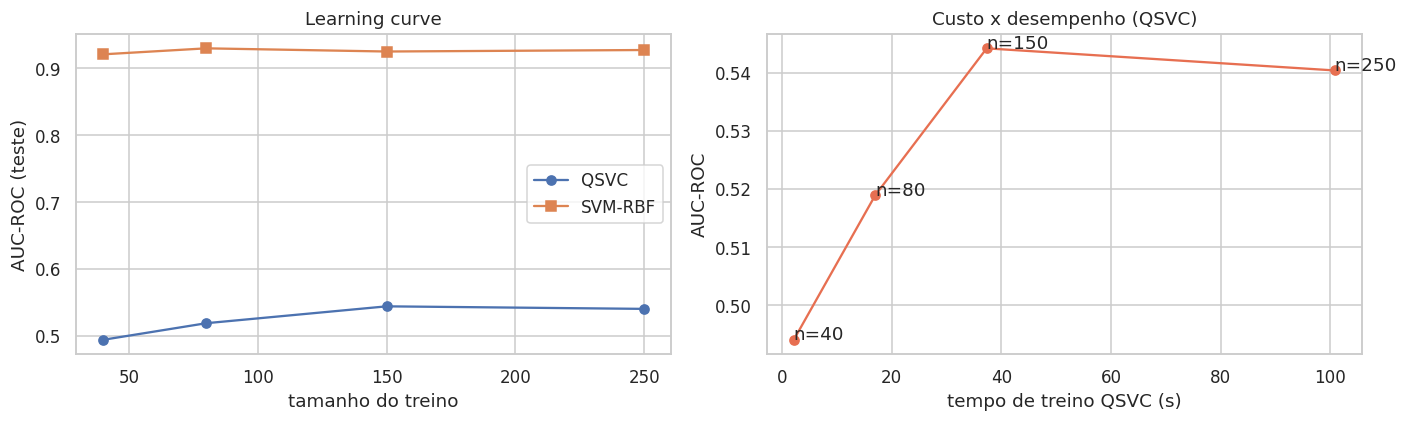

In [18]:
# Learning curve do QSVC vs SVM classico (custo x desempenho)
sizes = [40, 80, 150, 250]
qsvc_auc, svm_auc, qsvc_time = [], [], []
for s in sizes:
    Xs, _, ys, _ = _tts(X_train_bal, y_train_bal, train_size=s,
                        random_state=SEED, stratify=y_train_bal)
    # QSVC
    t0 = time.time()
    m = QSVC(quantum_kernel=FidelityQuantumKernel(feature_map=feature_map),
             probability=True, random_state=SEED)
    m.fit(Xs, ys)
    qsvc_time.append(time.time() - t0)
    _, sc = get_scores(m, X_test); qsvc_auc.append(roc_auc_score(y_test, sc))
    # SVM
    m2 = SVC(kernel="rbf", probability=True, random_state=SEED); m2.fit(Xs, ys)
    _, sc2 = get_scores(m2, X_test); svm_auc.append(roc_auc_score(y_test, sc2))
    print(f"  n={s}: QSVC AUC={qsvc_auc[-1]:.3f} | SVM AUC={svm_auc[-1]:.3f} "
          f"| QSVC treino={qsvc_time[-1]:.1f}s")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(sizes, qsvc_auc, "o-", label="QSVC")
ax[0].plot(sizes, svm_auc, "s-", label="SVM-RBF")
ax[0].set_xlabel("tamanho do treino"); ax[0].set_ylabel("AUC-ROC (teste)")
ax[0].set_title("Learning curve"); ax[0].legend()
ax[1].plot(qsvc_time, qsvc_auc, "o-", color="#e76f51")
for x, yv, s in zip(qsvc_time, qsvc_auc, sizes):
    ax[1].annotate(f"n={s}", (x, yv))
ax[1].set_xlabel("tempo de treino QSVC (s)"); ax[1].set_ylabel("AUC-ROC")
ax[1].set_title("Custo x desempenho (QSVC)")
plt.tight_layout(); plt.show()


## 4. Análise dos resultados e conexão com o problema espacial

### 4.1 Interpretação do desempenho

Os resultados foram claros e contrastantes. Os modelos clássicos atingiram desempenho forte
(SVM-RBF com AUC 0,926 e F1 0,836; Random Forest com AUC 0,907 e F1 0,800), enquanto os modelos
quânticos ficaram muito aquém — QSVC com AUC 0,541 e VQC com AUC 0,572, pouco acima do nível de um
classificador aleatório (0,500). As curvas ROC e as matrizes de confusão confirmam isso: as curvas
quânticas praticamente seguem a diagonal de referência.

Algumas causas explicam o resultado. Primeiro, o PCA concentrou a variância de forma extrema (a
1ª componente responde por 82,4% e as duas primeiras por 98,6%), de modo que, das quatro dimensões
codificadas nos quatro qubits, duas carregam quase nenhuma informação — e o kernel de fidelidade
resultante torna-se pouco discriminativo nesse regime de poucos qubits e poucas amostras. Segundo,
a curva de convergência do VQC mostra a perda caindo de ~1,30 e estagnando em ~0,99 a partir da
iteração 50: o COBYLA atingiu um platô que não separa bem as classes (comportamento compatível com
*barren plateaus* e com o limite de 80 iterações).

Há ainda o custo: o QSVC levou 162,8 s para treinar e 1925 ms por amostra na inferência — cerca de
cem mil vezes mais lento que o SVM clássico (0,015 ms). Para um sistema embarcado em satélite, com
restrição de energia e tempo de resposta, essa diferença é decisiva.

### 4.2 Limitações NISQ e ruído quântico

(i) **Expressividade vs. dados:** com poucos qubits e poucas amostras, o kernel quântico não
capturou estrutura útil e ainda impôs custo elevado. (ii) **Barren plateaus:** o platô na
convergência do VQC ilustra a dificuldade da otimização variacional. (iii) **Custo de simulação e
ruído:** a simulação do kernel exige da ordem de n² avaliações de circuito, e em hardware real o
ruído de portas e a decoerência degradariam ainda mais o resultado do simulador ideal.

### 4.3 Conexão com o problema espacial e os ODS

A detecção de anomalias em telemetria sustenta a manutenção autônoma de satélites e estações
remotas, onde decisões precisam ocorrer na borda — conectando o trabalho ao **ODS 9** (infraestrutura
e inovação) e ao **ODS 13** (ação climática). À luz dos resultados, a solução embarcável hoje é a
clássica. Isso prolonga o achado do nosso projeto de Computação Neuromórfica: se o gargalo dominante
é o custo computacional e o movimento de dados, uma arquitetura alternativa só se justifica quando
entrega ganho real — o que o QML ainda não faz neste caso.

### 4.4 Roadmap de adoção
1. **Curto prazo:** baselines clássicos embarcados (maduros, rápidos, baratos) para triagem na borda.
2. **Médio prazo:** reservar o QML para problemas com correlação de alta ordem, testando outros
   feature maps e ansätze e evitando a compressão agressiva de dimensionalidade.
3. **Longo prazo:** com hardware tolerante a falhas, reavaliar a vantagem quântica em larga escala.

In [19]:
# Resumo executivo automatico (impresso ao final)
melhor_auc = max(resultados, key=lambda r: r["AUC-ROC"])
print("="*60)
print("RESUMO EXECUTIVO (gerado automaticamente)")
print("="*60)
for r in resultados:
    print(f"{r['Modelo']:28s} AUC={r['AUC-ROC']:.3f} F1={r['F1']:.3f} "
          f"Acc={r['Acuracia']:.3f} treino={r['Tempo treino (s)']:.2f}s")
print("-"*60)
print(f"Melhor AUC-ROC: {melhor_auc['Modelo']} ({melhor_auc['AUC-ROC']:.3f})")
print(f"PCA: {var_exp.sum():.1%} de variancia explicada com {N_QUBITS} componentes")
print(f"Treino quantico: {len(X_q)} amostras | Teste: {len(X_test)} amostras")
print("="*60)

RESUMO EXECUTIVO (gerado automaticamente)
QSVC (quantico)              AUC=0.541 F1=0.431 Acc=0.517 treino=162.81s
VQC (quantico)               AUC=0.572 F1=0.465 Acc=0.528 treino=86.86s
SVM-RBF (classico)           AUC=0.926 F1=0.836 Acc=0.878 treino=0.01s
Random Forest (classico)     AUC=0.907 F1=0.800 Acc=0.856 treino=0.34s
------------------------------------------------------------
Melhor AUC-ROC: SVM-RBF (classico) (0.926)
PCA: 99.9% de variancia explicada com 4 componentes
Treino quantico: 300 amostras | Teste: 180 amostras


## 5. Conclusões, limitações e próximos passos

- Implementamos um pipeline híbrido quântico-clássico completo e reprodutível para detecção de
  anomalias em telemetria espacial, comparando QSVC e VQC com baselines clássicos sob avaliação justa.
- Neste problema e no atual regime NISQ, os modelos clássicos superaram amplamente os quânticos
  (AUC 0,93 contra 0,54-0,57), que ficaram próximos do nível aleatório e ainda com custo
  computacional muito maior. Investigamos as causas: concentração extrema da variância pelo PCA,
  kernel de fidelidade pouco discriminativo com poucos qubits/amostras e platô de convergência do VQC.
- **Limitações:** custo de simulação, sensibilidade do VQC à otimização e ausência de execução em
  hardware quântico real.
- **Próximos passos:** testar outros feature maps e ansätze, reduzir menos a dimensionalidade antes
  do encoding, usar um dataset real (NASA POWER/MSAD) e reavaliar a vantagem quântica em hardware
  tolerante a falhas.

### Referências
As referências completas (formato ABNT, incluindo NASA e ESA) estão no relatório em PDF.